<a href="https://colab.research.google.com/github/Kartikpatil726/ML_Practical_/blob/main/ML_Practical1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

• Student Name : Kartik Dattatray Patil

• Div: B

• Practical Batch : B-1

• Roll No : 29

• Date : 02/09/2026

• Practical NO : 01

• Practical Name : Implement simple and multiple linear regression using Numpy and using Scikit-learn. Plot regression lines and residuals. Compute RMSE and R2 values.


In [3]:
# 1] Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# 2] Data Collection
# Create the dataset
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Attendance": [60, 85, 70, 95, 65, 80, 90, 75, 88, 72],
    "Marks": [32, 42, 47, 58, 61, 67, 76, 79, 88, 91]
}

In [5]:
# Convert dict into DataFrame
df = pd.DataFrame(data)
print(df)

   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


In [6]:
# 3] EDA And Preprocessing
print('First Five Rows:')
df.head(3)

First Five Rows:


,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47


In [7]:
df.tail()

print('Shape of Dataset:')
df.shape

print('Information:')
df.info()

print('Statistical Analysis:\n', df.describe())

print('Check for null values:')
df.isnull().sum()

df = df.dropna()
df

Shape of Dataset:
Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes
Statistical Analysis:
        Study_Hours  Attendance      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.489125  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000  91.000000
Check for null values:


,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


In [8]:
# Duplicate Values
df.duplicated().sum()

df = df.drop_duplicates()
df

,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


In [9]:
# Data Visualization
df_corr = df.corr()
df_corr

,Study_Hours,Attendance,Marks
Study_Hours,1.000000,0.245955,0.994877
Attendance,0.245955,1.000000,0.331320
Marks,0.994877,0.331320,1.000000


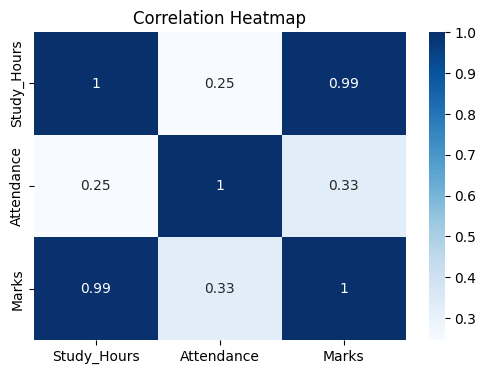

In [10]:
# Correlation Heatmap
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(df_corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
# A] Simple Linear Regression by Using Sckit-learn
# Feature Selection
x = df[['Study_Hours']]  # Independent Variable
y = df['Marks']          # Dependent Variable
x

,Study_Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [12]:
# 4] Model Building
# Split dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
x_test

,Study_Hours
8,9
1,2
5,6


In [13]:
# Import Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

LinearRegression()

In [14]:
# Predict the values
y_pred = model.predict(x_test)
y_pred

# Print Equation
print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])

Intercept: 28.277227722772274
Slope: 6.475247524752477


In [15]:
# SLR Equation
# Marks = (6.48 * Study_Hours) + 28.27

In [16]:
# 5] Model Evaluation
# Evaluation
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RSME:', round(rmse, 3))
print('R2 Score:', round(r2, 2))

RSME: 0.949
R2 Score: 1.0


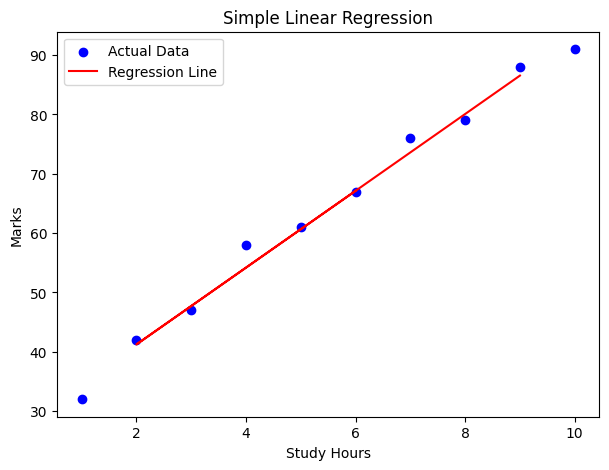

In [17]:
# Regression Line
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, y_pred, color='red', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

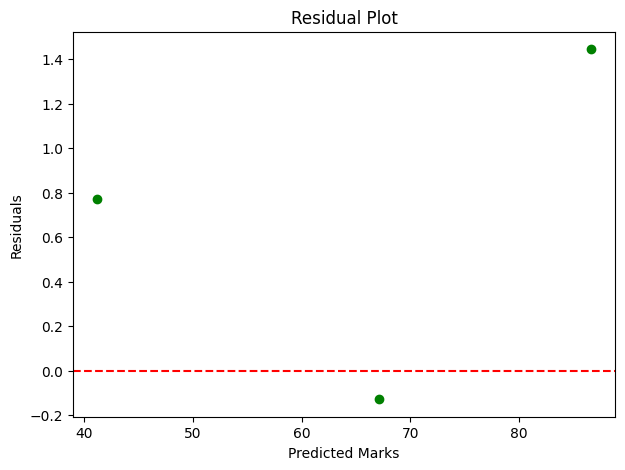

In [18]:
 # Residual Plot
residuals = y_test - y_pred  # Calculate Residual
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle="--")
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [19]:
# B] Simple Linear Regression by using Numpy
x = df["Study_Hours"].values  # Independent Variable (Features)
y = df["Marks"].values        # Dependent Variable (Target)
x

# Calculate mean
x_mean = np.mean(x)
y_mean = np.mean(y)
x_mean

np.float64(5.5)

In [20]:
# Calculate slope
m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)

In [21]:
# Calculate intercept
b = y_mean - m * x_mean

print("Slope =", m)
print("Intercept =", b)

Slope = 6.503030303030303
Intercept = 28.33333333333333


In [22]:
# Prediction
y_pred_numpy = m * x + b
y_pred_numpy

array([34.83636364, 41.33939394, 47.84242424, 54.34545455, 60.84848485,
       67.35151515, 73.85454545, 80.35757576, 86.86060606, 93.36363636])

In [23]:
# C] Multiple Linear Regression
# Feature Selection
x = df[['Study_Hours', 'Attendance']]  # Independent Variables
y = df['Marks']                        # Dependent Variable

# Split Dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
x_train

,Study_Hours,Attendance
0,1,60
7,8,75
2,3,70
9,10,72
4,5,65
3,4,95
6,7,90


In [24]:
# Model Building
model = LinearRegression()
model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)
y_pred

array([88.08653885, 43.59718321, 67.84336712])

In [25]:
# Model Parameters
print('Intercept:', model.intercept_)
print("Coefficients:")
coeff = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_})
print(coeff)

Intercept: 16.14458419831481
Coefficients:
       Feature  Coefficient
0  Study_Hours     6.280539
1   Attendance     0.175194


In [27]:
# Model Evalution
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
print('Metrics Values of MLR:')
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)
print('RMSE:', round(rmse, 2))
print('R2 Score:', round(r2, 2))

Metrics Values of MLR:
MAE: 0.8423630615595409
RMSE: 1.04
R2 Score: 1.0


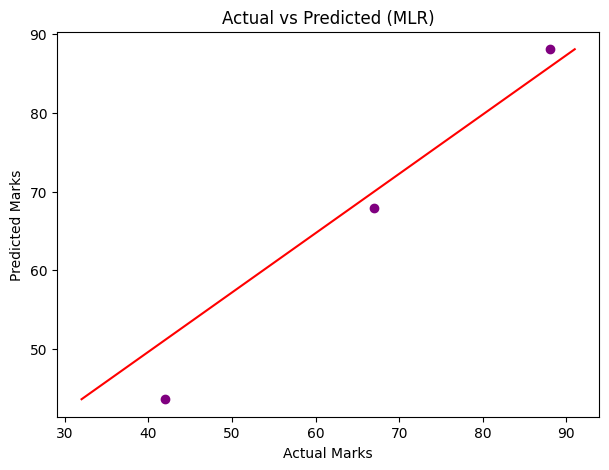

In [28]:
# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='Purple')
# Perfect Prediction Line
plt.plot([y.min(), y.max()], [y_pred.min(), y_pred.max()], color='red')
plt.xlabel('Actual Marks')
plt.ylabel("Predicted Marks")
plt.title('Actual vs Predicted (MLR)')
plt.show()

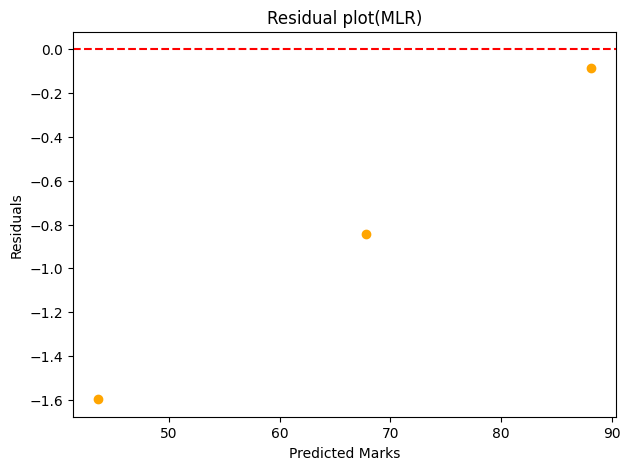

In [29]:
# Residual Plot
residuals = y_test - y_pred  # calculate residual
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='Orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual plot(MLR)')
plt.show()
